<a href="https://colab.research.google.com/github/kadentowle/DSC110/blob/main/ML_Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMPORTING PANDAS AND DATA**

In [2]:
# ---------- IMPORTS ----------

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

X_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/X_train.csv')
X_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/X_test.csv')
y_train = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/y_train.csv')
y_test = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/y_test.csv')


We need the confusion matrix and random forest classifer to train and evaluate the ML model.

# **TRAINGING THE ML MODEL**

In [3]:
# ---------- CODE ---------

y_train = y_train.squeeze()
y_test  = y_test.squeeze()

# **BUILDING THE RANDOM FOREST MODEL**

In [4]:
# ---------- BUILDING RF MODEL ---------

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

This random forest model is our first ML model.

# **EVALUATING RANDOM FOREST MODEL**

In [7]:

# ---------- DIFFERENT CLASSIFICATIONS ---------

from sklearn.metrics import classification_report, roc_auc_score

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred, labels=[1]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1289
           1       0.29      0.06      0.11       216

    accuracy                           0.84      1505
   macro avg       0.58      0.52      0.51      1505
weighted avg       0.78      0.84      0.80      1505

              precision    recall  f1-score   support

           1       0.29      0.06      0.11       216

   micro avg       0.29      0.06      0.11       216
   macro avg       0.29      0.06      0.11       216
weighted avg       0.29      0.06      0.11       216

AUC-ROC: 0.7488


This evaluates the RF model's accuracy and averages.

# **THRESHOLDS AND CONFUSION MATRIX**

In [9]:
# ---------- THRESHOLDS ----------

y_pred_03 = (y_prob >= 0.3).astype(int) # This changes the threshold to 0.3

Changing the threshold can make the ML model more or less sensitive.

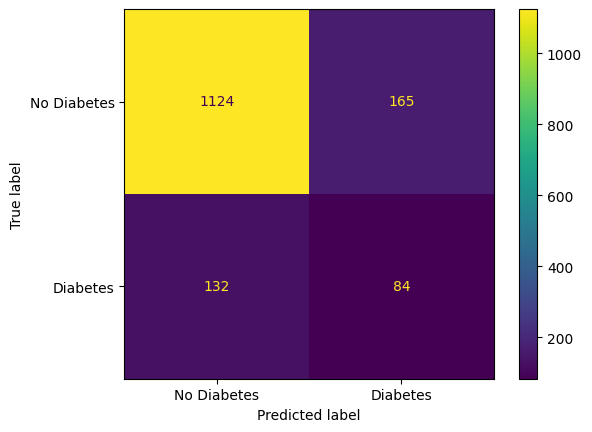

In [10]:

# --------- CONFUSION MATRIX DISPLAY ---------

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_03, display_labels=['No Diabetes', 'Diabetes'])
plt.show() # Displays a heatmap for the

This categorises the data into the number of samples (individuals) who fit into each category, such as 1124 people who were correctly categorized as diebetic and 165 false positives.